# CarDekho Used Car Resale Price Prediction With Three Models

**Introduction to Data Science mid term group project**  
**Problem type:** supervised regression  
**Submission dataset:** Car details v3, embedded in this notebook so no separate CSV upload is needed

We use historical used-car listings to estimate a vehicle's listed selling price in Indian rupees. A dealer or seller could use the estimate as a starting point for pricing, but it is not an appraisal or a guaranteed sale price. This notebook documents a reproducible Python analysis from raw data to an independent test result. The separate CarDekho website is a demonstration interface; the model selection in this notebook is based on cross-validation and may differ from the website's earlier validation-selected model.

## 1 Business understanding

**Stakeholder:** a used-car seller or dealer reviewing a proposed listing price. **Decision:** whether a proposed asking price is broadly consistent with comparable historical listings. **Success:** lower prediction error than a median-price baseline on untouched test listings, with transparent limitations. The target is `selling_price` in INR. We compare Linear Regression, Random Forest and Gradient Boosting, plus a median-price benchmark.

The embedded file has 8,128 raw rows and 13 source columns, satisfying the minimum 1,000 rows and 8 columns. This is one dataset, not a merger of all four files in the development repository. Dataset approval and uniqueness within the class must be confirmed separately by the group.

In [1]:
# Embedded copy of the original CSV. Hidden in most notebook viewers; no external file is read.
_DATA_GZIP_BASE64 = (
    '...'
    '4CFjPcL7zxV/3u/wAwIDmU5eQPAA=='
)

In [2]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, RandomizedSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import sklearn

RANDOM_STATE = 42
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 30)
import base64, gzip, hashlib, io
dataset_bytes = gzip.decompress(base64.b64decode(_DATA_GZIP_BASE64))
assert hashlib.sha256(dataset_bytes).hexdigest() == '1b2a30b2f36fd246366773fe5375399692f1a113890ad2a6d464b8c8deaadadb', 'Embedded dataset checksum mismatch'
raw = pd.read_csv(io.BytesIO(dataset_bytes))
print('Dataset: embedded Car details v3.csv | pandas:', pd.__version__, '| scikit-learn:', sklearn.__version__)
print('Raw shape:', raw.shape)
display(raw.head(5))

Dataset: embedded Car details v3.csv | pandas: 3.0.6 | scikit-learn: 1.6.1
Raw shape: (8128, 13)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


## 2 Data understanding

We inspect types, missing cells, duplicates, prices and simple relationships before fitting a model. Listed prices are skewed, so mean error alone can hide difficult expensive vehicles. The `torque` text mixes several formats and units; we exclude it rather than pretending it has one consistent numeric scale. Mileage strings also mix km/l and km/kg, so fuel remains a separate feature and the mileage coefficient should not be interpreted causally.

### Source data dictionary

| Source column | Meaning and treatment |
|---|---|
| `name` | Listing's make and model text; normalized as `vehicle_name`, with its first word also used as `brand`. |
| `year` | Vehicle model year; numeric predictor. |
| `selling_price` | Listed selling price in INR; regression target, never a predictor. |
| `km_driven` | Odometer distance in kilometres; numeric predictor. |
| `fuel` | Fuel category; categorical predictor. |
| `seller_type` | Seller category; categorical predictor. |
| `transmission` | Manual or automatic category; categorical predictor. |
| `owner` | Prior ownership category; categorical predictor. |
| `mileage` | Source text such as kmpl or km/kg; the leading number is parsed, with unit caveat. |
| `engine` | Source text in cubic centimetres; the numeric part is parsed. |
| `max_power` | Source text in brake horsepower; the numeric part is parsed. |
| `torque` | Mixed text and units; excluded rather than treated as a consistent number. |
| `seats` | Seating capacity; numeric predictor. |

`brand` and `vehicle_name` are derived features, not extra source columns. The raw file has no supplied condition, accident-history or transaction-completion fields.

,dtype,missing,unique
name,str,0,2058
year,int64,0,29
selling_price,int64,0,677
km_driven,int64,0,921
fuel,str,0,4
seller_type,str,0,3
transmission,str,0,2
owner,str,0,5
mileage,str,221,393
engine,str,221,121


Exact duplicate rows: 1202


,INR
count,8.128000e+03
mean,6.382718e+05
std,8.062534e+05
min,2.999900e+04
10%,1.500000e+05
25%,2.549990e+05
50%,4.500000e+05
75%,6.750000e+05
90%,1.025000e+06
95%,1.950000e+06


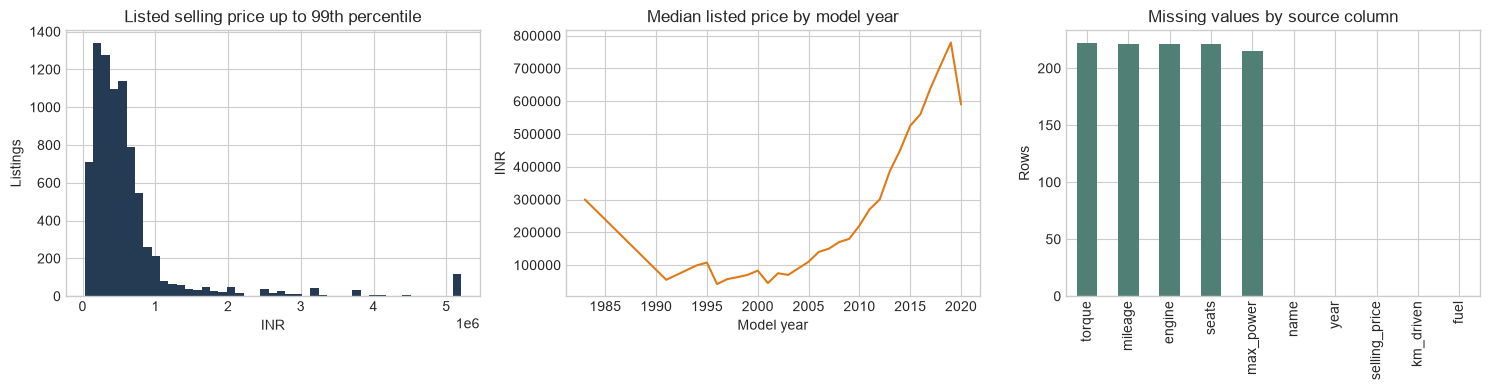

Interpretation: the chart describes associations in historical listings, not the causal effect of age or mileage.


In [3]:
summary = pd.DataFrame({'dtype': raw.dtypes.astype(str), 'missing': raw.isna().sum(), 'unique': raw.nunique(dropna=True)})
display(summary)
print('Exact duplicate rows:', raw.duplicated().sum())
display(raw['selling_price'].describe(percentiles=[.1, .25, .5, .75, .9, .95, .99]).to_frame('INR'))
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
raw['selling_price'].dropna().clip(upper=raw['selling_price'].quantile(.99)).hist(bins=45, ax=axes[0], color='#243b53')
axes[0].set(title='Listed selling price up to 99th percentile', xlabel='INR', ylabel='Listings')
raw.groupby('year')['selling_price'].median().plot(ax=axes[1], color='#e07a17')
axes[1].set(title='Median listed price by model year', xlabel='Model year', ylabel='INR')
raw.isna().sum().sort_values(ascending=False).head(10).plot.bar(ax=axes[2], color='#508075')
axes[2].set(title='Missing values by source column', ylabel='Rows')
plt.tight_layout(); plt.show()
print('Interpretation: the chart describes associations in historical listings, not the causal effect of age or mileage.')

## 3 Data preparation

We remove exact duplicates, parse numeric measurements, derive `brand` from the first word of `name`, and retain the full normalized vehicle name. We discard rows without a positive target or a valid model year and kilometre reading. Other missing feature values remain missing until the training pipeline learns imputations. We do **not** drop extreme prices by inspecting the test set. The feature set contains six numeric and six categorical inputs.

We split by a hash of the complete feature row so identical feature combinations cannot appear in both development and test sets, even when their listed prices differ. All imputers, one-hot encoding and numeric scaling are fitted inside the pipeline on each training fold. Scaling does not improve tree splits in principle, but it makes the linear model comparable and satisfies a consistent preprocessing workflow.

In [4]:
data = raw.drop_duplicates().copy()
data['vehicle_name'] = data['name']
data['brand'] = data['name'].astype('string').str.split().str[0]
numeric = ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
categorical = ['brand', 'vehicle_name', 'fuel', 'seller_type', 'transmission', 'owner']
features = numeric + categorical
for col in ['mileage', 'engine', 'max_power']:
    data[col] = pd.to_numeric(data[col].astype('string').str.extract(r'(\d+(?:\.\d+)?)')[0], errors='coerce').astype(float)
    data.loc[data[col] <= 0, col] = np.nan
for col in ['year', 'km_driven', 'seats', 'selling_price']:
    data[col] = pd.to_numeric(data[col], errors='coerce')
for col in categorical:
    data[col] = data[col].map(lambda value: str(value).strip().lower() if pd.notna(value) else np.nan).replace('', np.nan)
data = data.replace([np.inf, -np.inf], np.nan)
valid = data['selling_price'].notna() & (data['selling_price'] > 0) & data['year'].between(1886, 2100) & (data['km_driven'] >= 0) & data['km_driven'].notna()
data = data.loc[valid, features + ['selling_price']].drop_duplicates().reset_index(drop=True)
print('Clean rows:', len(data), '| Features:', len(features), '| Missing feature cells:', int(data[features].isna().sum().sum()))
display(data[features + ['selling_price']].head(3))
groups = pd.util.hash_pandas_object(data[features], index=False)
splitter = GroupShuffleSplit(n_splits=1, test_size=.20, random_state=RANDOM_STATE)
development_index, test_index = next(splitter.split(data, groups=groups))
X_dev, y_dev = data.loc[development_index, features], data.loc[development_index, 'selling_price']
X_test, y_test = data.loc[test_index, features], data.loc[test_index, 'selling_price']
dev_groups = groups.loc[development_index]
assert set(dev_groups).isdisjoint(set(groups.loc[test_index]))
print('Development rows:', len(X_dev), '| Untouched test rows:', len(X_test))

Clean rows: 6926 | Features: 12 | Missing feature cells: 848


,year,km_driven,mileage,engine,max_power,seats,brand,vehicle_name,fuel,seller_type,transmission,owner,selling_price
0,2014,145500,23.40,1248.0,74.00,5.0,maruti,maruti swift dzire vdi,diesel,individual,manual,first owner,450000
1,2014,120000,21.14,1498.0,103.52,5.0,skoda,skoda rapid 1.5 tdi ambition,diesel,individual,manual,second owner,370000
2,2006,140000,17.70,1497.0,78.00,5.0,honda,honda city 2017-2020 exi,petrol,individual,manual,third owner,158000


Development rows: 5539 | Untouched test rows: 1387


In [5]:
preprocess = ColumnTransformer([
    ('numeric', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), numeric),
    ('categorical', Pipeline([('impute', SimpleImputer(strategy='most_frequent')), ('encode', OneHotEncoder(handle_unknown='ignore', min_frequency=10, sparse_output=False))]), categorical),
])
models = {
    'Median baseline': DummyRegressor(strategy='median'),
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=120, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=2),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=120, learning_rate=.05, max_depth=3, loss='huber', random_state=RANDOM_STATE),
}
pipelines = {name: Pipeline([('preprocess', preprocess), ('model', model)]) for name, model in models.items()}
cv = GroupKFold(n_splits=3)
splits = list(cv.split(X_dev, y_dev, groups=dev_groups))
assert all(set(dev_groups.iloc[train]).isdisjoint(set(dev_groups.iloc[valid])) for train, valid in splits)
print('Three group-separated cross-validation folds prepared.')

Three group-separated cross-validation folds prepared.


## 4 Modelling and cross validation

The median-price baseline ignores vehicle details. We compare it with three regressors using the **same** three group-separated folds on the development set. RMSE (lower is better) selects the leading candidate; MAE and R² provide additional context. We do not inspect the independent test result to choose a model. Cross-validation estimates can still vary on a different sample, especially for rare luxury cars.

,model,CV RMSE INR,CV MAE INR,CV R2
0,Random Forest,"₹188,199","₹84,154",0.869
1,Gradient Boosting,"₹224,681","₹93,558",0.814
2,Linear Regression,"₹275,394","₹140,444",0.722
3,Median baseline,"₹535,326","₹280,325",-0.050


Best untuned candidate by CV RMSE: Random Forest
Baseline CV RMSE: ₹535,326 | Candidate CV RMSE: ₹188,199


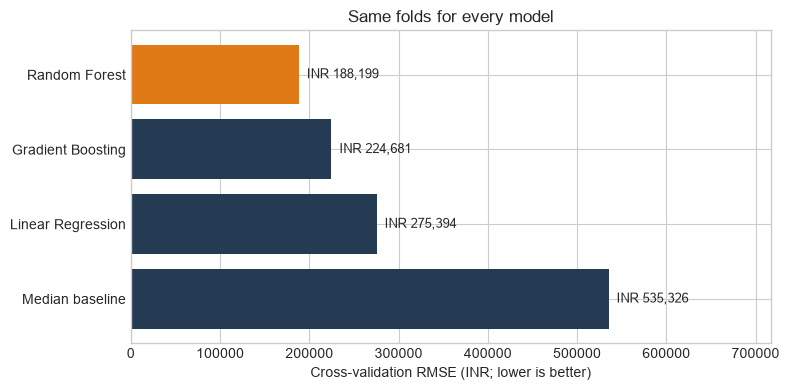

In [6]:
scoring = {'rmse': 'neg_root_mean_squared_error', 'mae': 'neg_mean_absolute_error', 'r2': 'r2'}
cv_rows = []
for name, pipeline in pipelines.items():
    scores = cross_validate(pipeline, X_dev, y_dev, cv=splits, scoring=scoring, n_jobs=1, error_score='raise')
    cv_rows.append({'model': name, 'CV RMSE INR': -scores['test_rmse'].mean(), 'CV MAE INR': -scores['test_mae'].mean(), 'CV R2': scores['test_r2'].mean()})
cv_results = pd.DataFrame(cv_rows).sort_values('CV RMSE INR').reset_index(drop=True)
display(cv_results.style.format({'CV RMSE INR': '₹{:,.0f}', 'CV MAE INR': '₹{:,.0f}', 'CV R2': '{:.3f}'}))
candidate = cv_results.loc[cv_results['model'] != 'Median baseline'].iloc[0]['model']
baseline_cv_rmse = cv_results.loc[cv_results['model'] == 'Median baseline', 'CV RMSE INR'].iloc[0]
before_cv_rmse = cv_results.loc[cv_results['model'] == candidate, 'CV RMSE INR'].iloc[0]
print('Best untuned candidate by CV RMSE:', candidate)
print('Baseline CV RMSE:', f'₹{baseline_cv_rmse:,.0f}', '| Candidate CV RMSE:', f'₹{before_cv_rmse:,.0f}')
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(cv_results['model'][::-1], cv_results['CV RMSE INR'][::-1], color=['#243b53' if name != candidate else '#e07a17' for name in cv_results['model'][::-1]])
ax.set(xlabel='Cross-validation RMSE (INR; lower is better)', title='Same folds for every model')
for bar in bars: ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f'  INR {bar.get_width():,.0f}', va='center', fontsize=9)
ax.set_xlim(0, cv_results['CV RMSE INR'].max()*1.34)
plt.tight_layout(); plt.show()

## 5 Model selection and tuning

We tune only the best non-baseline candidate from cross-validation with a small, reproducible randomized search. The search sees development folds only. The table prints the candidate's CV RMSE **before and after tuning**. A modest improvement is possible; a worse tuned result is also possible because selecting the maximum across a small search is noisy. The untouched test set is used only after this choice is complete.

In [7]:
search_spaces = {
    'Linear Regression': {'model__fit_intercept': [True, False]},
    'Random Forest': {'model__n_estimators': [80, 120, 180], 'model__max_depth': [12, 20, None], 'model__min_samples_leaf': [1, 2, 4]},
    'Gradient Boosting': {'model__n_estimators': [80, 120, 180], 'model__learning_rate': [.03, .05, .08], 'model__max_depth': [2, 3]},
}
search = RandomizedSearchCV(
    pipelines[candidate], search_spaces[candidate], n_iter=2 if candidate == 'Linear Regression' else 4,
    scoring='neg_root_mean_squared_error', cv=splits, random_state=RANDOM_STATE,
    n_jobs=1, refit=True, error_score='raise',
)
search.fit(X_dev, y_dev)
tuned = search.best_estimator_
after_cv_rmse = -search.best_score_
display(pd.DataFrame({'stage': ['Before tuning', 'After tuning'], 'CV RMSE INR': [before_cv_rmse, after_cv_rmse]}).style.format({'CV RMSE INR': '₹{:,.0f}'}))
print('Tuned model:', candidate, '| Best settings:', search.best_params_)

,stage,CV RMSE INR
0,Before tuning,"₹188,199"
1,After tuning,"₹183,280"


Tuned model: Random Forest | Best settings: {'model__n_estimators': 80, 'model__min_samples_leaf': 1, 'model__max_depth': 20}


## 6 Independent evaluation

We now fit each fixed candidate on all development rows and evaluate it once on the held-out test rows. The tuned candidate is also evaluated here. These are **independent test metrics**, not training accuracy or a confidence score for an individual car. MAE is the mean absolute rupee error; RMSE penalizes large misses more; R² measures variation explained relative to a constant-mean reference. The median baseline gives a simple business benchmark.

,model,Test MAE INR,Test RMSE INR,Test R2
0,Random Forest tuned,"₹72,457","₹129,392",0.935
1,Random Forest,"₹73,083","₹131,226",0.933
2,Gradient Boosting,"₹85,412","₹186,451",0.865
3,Linear Regression,"₹136,519","₹274,571",0.708
4,Median baseline,"₹268,210","₹518,471",-0.042


Tuned model test RMSE reduction vs median baseline: 75.0%


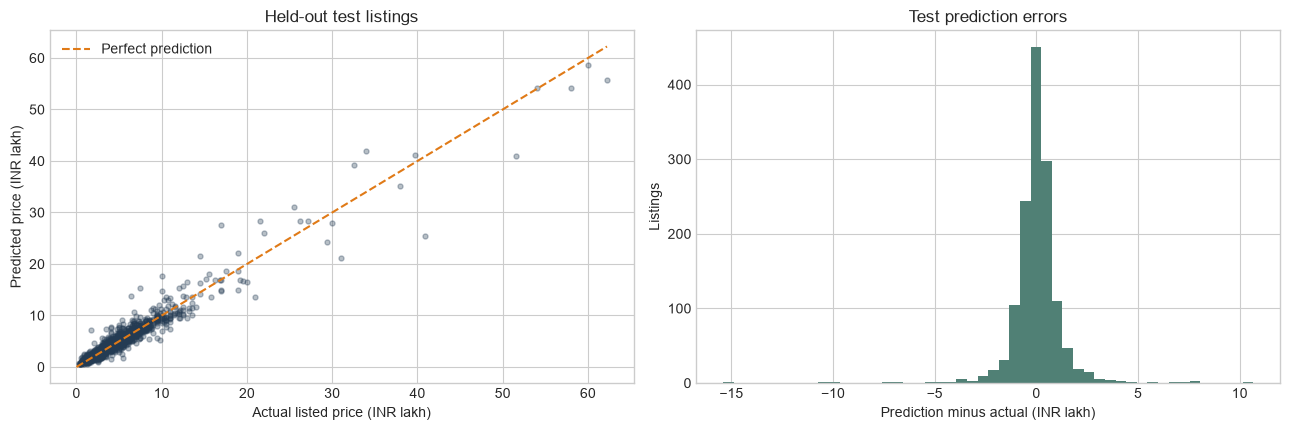

In [8]:
def evaluate(y_true, predicted):
    return {'Test MAE INR': mean_absolute_error(y_true, predicted),
            'Test RMSE INR': mean_squared_error(y_true, predicted)**.5,
            'Test R2': r2_score(y_true, predicted)}

test_rows = []
for name, pipeline in pipelines.items():
    fitted = pipeline.fit(X_dev, y_dev)
    test_rows.append({'model': name, **evaluate(y_test, fitted.predict(X_test))})
predicted = tuned.predict(X_test)
test_rows.append({'model': f'{candidate} tuned', **evaluate(y_test, predicted)})
test_results = pd.DataFrame(test_rows).sort_values('Test RMSE INR').reset_index(drop=True)
display(test_results.style.format({'Test MAE INR': '₹{:,.0f}', 'Test RMSE INR': '₹{:,.0f}', 'Test R2': '{:.3f}'}))
baseline_test_rmse = test_results.loc[test_results['model'] == 'Median baseline', 'Test RMSE INR'].iloc[0]
tuned_test_rmse = test_results.loc[test_results['model'] == f'{candidate} tuned', 'Test RMSE INR'].iloc[0]
print('Tuned model test RMSE reduction vs median baseline:', f'{(1 - tuned_test_rmse/baseline_test_rmse)*100:.1f}%')
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
axes[0].scatter(y_test/100000, predicted/100000, s=13, alpha=.32, color='#243b53')
limit = max(y_test.max(), predicted.max())/100000
axes[0].plot([0, limit], [0, limit], '--', color='#e07a17', label='Perfect prediction')
axes[0].set(xlabel='Actual listed price (INR lakh)', ylabel='Predicted price (INR lakh)', title='Held-out test listings')
axes[0].legend()
residual = (predicted - y_test.to_numpy())/100000
axes[1].hist(residual, bins=50, color='#508075')
axes[1].set(xlabel='Prediction minus actual (INR lakh)', ylabel='Listings', title='Test prediction errors')
plt.tight_layout(); plt.show()

## 7 Example test predictions and feature importance

These examples come from held-out test rows, not from the data used to fit the final estimator. We show vehicles across the observed price range and a difficult large-error case. A single estimate should not be presented as exact market value. Permutation importance measures how much shuffling one input worsens held-out MAE; correlated features and high-cardinality names can make this unstable. It is not a causal effect.

,vehicle_name,year,km_driven,fuel,actual_inr,predicted_inr,absolute_error_inr
382,chevrolet spark 1.0 ls,2011,"80,000",petrol,"₹150,000","₹153,720","₹3,720"
122,hyundai i10 asta,2008,"98,000",petrol,"₹275,000","₹177,924","₹97,076"
21,ford freestyle titanium petrol bsiv,2020,"5,000",petrol,"₹400,000","₹655,396","₹255,396"
603,maruti ertiga vdi,2015,"68,000",diesel,"₹571,000","₹639,277","₹68,277"
336,toyota innova 2.5 vx (diesel) 7 seater,2014,"217,000",diesel,"₹869,999","₹1,110,198","₹240,199"
618,mercedes-benz gl-class 350 cdi luxury,2016,"70,000",diesel,"₹4,090,000","₹2,548,625","₹1,541,375"


,"Increase in MAE when shuffled, INR"
max_power,"149,027"
year,"148,681"
engine,"30,509"
mileage,"13,131"
brand,"12,798"
km_driven,"6,726"
seats,"2,289"
fuel,"1,993"
owner,798
seller_type,617


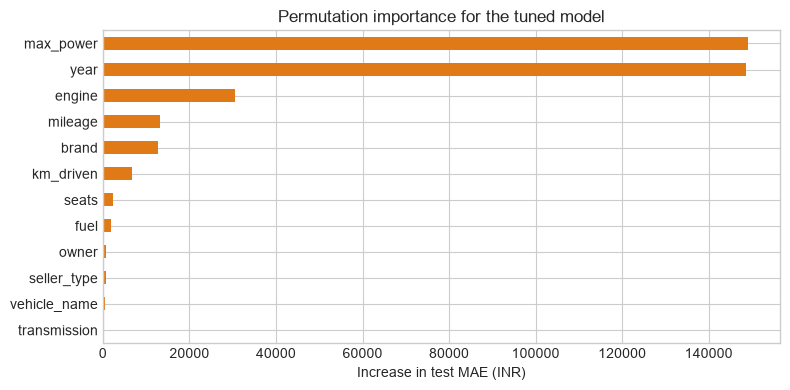

In [9]:
examples = X_test[['vehicle_name', 'year', 'km_driven', 'fuel']].copy().reset_index(drop=True)
examples['actual_inr'] = y_test.to_numpy()
examples['predicted_inr'] = predicted
examples['absolute_error_inr'] = np.abs(examples['predicted_inr'] - examples['actual_inr'])
positions = [int((examples['actual_inr'] - examples['actual_inr'].quantile(q)).abs().idxmin()) for q in [.1,.3,.5,.7,.9]]
positions.append(int(examples['absolute_error_inr'].idxmax()))
display(examples.iloc[list(dict.fromkeys(positions))].style.format({'km_driven': '{:,.0f}', 'actual_inr': '₹{:,.0f}', 'predicted_inr': '₹{:,.0f}', 'absolute_error_inr': '₹{:,.0f}'}))
importance = permutation_importance(tuned, X_test, y_test, scoring='neg_mean_absolute_error', n_repeats=2, random_state=RANDOM_STATE, n_jobs=1)
important = pd.Series(importance.importances_mean, index=features).sort_values(ascending=False)
display(important.to_frame('Increase in MAE when shuffled, INR').style.format('{:,.0f}'))
fig, ax = plt.subplots(figsize=(8, 4))
important.sort_values().plot.barh(ax=ax, color='#e07a17')
ax.set(xlabel='Increase in test MAE (INR)', title='Permutation importance for the tuned model')
plt.tight_layout(); plt.show()

## 8 Business recommendation and limitations

The selected Python pipeline can support a **price review**, not an automatic final quote. A dealer should compare the estimate with recent local listings, vehicle condition and documented service history before deciding an asking price. Review the test MAE and the high-error examples when deciding how much human review is needed. The dataset records listed selling prices, not verified sale transactions; it lacks condition, accident history and detailed regional demand. Unusual luxury models and older records may be poorly represented. The source's mileage units depend on fuel type, and torque was excluded due to inconsistent formatting. The model should be retrained and monitored on newer, consented data before any real marketplace use.

**Reproducibility and attribution:** This notebook uses the supplied `Car details v3.csv` file and Python libraries pandas, matplotlib and scikit-learn. AI assistance was used to help structure and check the code and written explanations; the group must be able to explain and verify every step. The group must add its approved dataset source link, membership and individual contributions to the slide deck before submission. The notebook contains no scraped personal identities or fabricated model scores.